# NHS Drug Distribution Equity Analysis

## A Healthcare Analytics Project Inspired by NHS Medicine Distribution Challenges in Staffordshire

This project explores healthcare inequalities, medicine shortages, and deprivation-linked distribution patterns using simulated NHS prescribing data inspired by real-world NHS healthcare analytics problems.

The analysis demonstrates:
- Data cleaning
- Exploratory data analysis
- Feature engineering
- Visualisation
- Correlation analysis
- Basic predictive modelling

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
import plotly.express as px

In [18]:
## Load DataSet

df = pd.read_csv('sample_dataset.csv')

df.head()

,region,drug_name,drug_category,items_prescribed,cost,deprivation_score,shortage_incidents,pharmacy_density,year
0,Newcastle-under-Lyme,Quetiapine,Mental Health,70,4003.06,16,161,1.40,2024
1,East Staffordshire,Lansoprazole,General Medicine,358,4344.26,11,127,2.28,2023
2,Cannock Chase,Paracetamol,General Medicine,363,990.94,21,128,1.58,2024
3,East Staffordshire,Morphine Sulfate,General Medicine,293,4871.40,12,90,2.08,2022
4,Stafford and Surroundings,Quetiapine,Mental Health,395,165.00,11,123,1.51,2024


In [19]:
## Data Overview

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   region              5000 non-null   object 
 1   drug_name           5000 non-null   object 
 2   drug_category       5000 non-null   object 
 3   items_prescribed    5000 non-null   int64  
 4   cost                4748 non-null   float64
 5   deprivation_score   5000 non-null   int64  
 6   shortage_incidents  5000 non-null   int64  
 7   pharmacy_density    5000 non-null   float64
 8   year                5000 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 351.7+ KB


In [ ]:
## CHECK MISSING VALUES

df.describe()

,items_prescribed,cost,deprivation_score,shortage_incidents,pharmacy_density,year
count,5000.000000,4748.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,322.575000,2580.835663,19.667600,128.840000,1.850168,2022.994000
std,158.309205,1409.263639,5.736418,51.741432,0.372219,0.815412
min,50.000000,100.770000,10.000000,40.000000,1.200000,2022.000000
25%,186.000000,1385.625000,15.000000,84.000000,1.530000,2022.000000
50%,323.500000,2611.960000,20.000000,128.000000,1.840000,2023.000000
75%,460.000000,3784.252500,25.000000,173.000000,2.170000,2024.000000
max,599.000000,4999.510000,29.000000,219.000000,2.500000,2024.000000


In [ ]:
## CHECK MISSING VALUES

df.isnull().sum()

region                  0
drug_name               0
drug_category           0
items_prescribed        0
cost                  252
deprivation_score       0
shortage_incidents      0
pharmacy_density        0
year                    0
dtype: int64

In [ ]:
## HANDLE MISSING VALUES

df['cost'] = df['cost'].fillna(df['cost'].median())

In [ ]:
## FEATURE ENGINEERING

df['cost_per_item'] = df['cost'] / df['items_prescribed']

df.head()

,region,drug_name,drug_category,items_prescribed,cost,deprivation_score,shortage_incidents,pharmacy_density,year,cost_per_item
0,Newcastle-under-Lyme,Quetiapine,Mental Health,70,4003.06,16,161,1.40,2024,57.186571
1,East Staffordshire,Lansoprazole,General Medicine,358,4344.26,11,127,2.28,2023,12.134804
2,Cannock Chase,Paracetamol,General Medicine,363,990.94,21,128,1.58,2024,2.729862
3,East Staffordshire,Morphine Sulfate,General Medicine,293,4871.40,12,90,2.08,2022,16.625939
4,Stafford and Surroundings,Quetiapine,Mental Health,395,165.00,11,123,1.51,2024,0.417722


In [ ]:
## REGIONAL ANALYSIS

region_summary = df.groupby('region')[['cost', 'items_prescribed', 'cost_per_item']].mean()

region_summary

,cost,items_prescribed,cost_per_item
region,,,
Cannock Chase,2602.807280,315.043521,12.286456
East Staffordshire,2585.076335,328.921610,11.721438
Newcastle-under-Lyme,2629.520929,324.567773,11.875560
Stafford and Surroundings,2555.233435,317.015748,12.096823
Stoke-on-Trent,2535.944230,327.881930,11.486717


In [ ]:
## DRUG CATEGORY ANALYSIS

category_summary = df.groupby('drug_category')['shortage_incidents'].mean()

category_summary

drug_category
Antibiotics         128.127789
Cardiovascular      128.188910
General Medicine    129.791588
Mental Health       127.014925
Name: shortage_incidents, dtype: float64

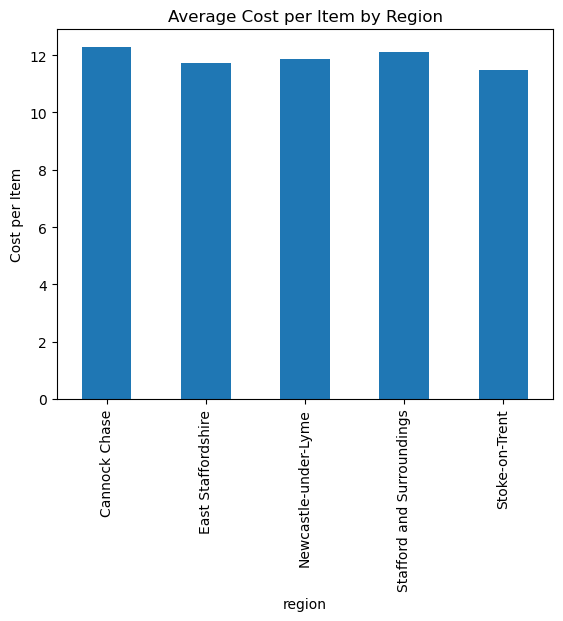

In [ ]:
## FIRST VISUALISATION

region_summary['cost_per_item'].plot(kind='bar')

plt.title('Average Cost per Item by Region')
plt.ylabel('Cost per Item')

plt.show()

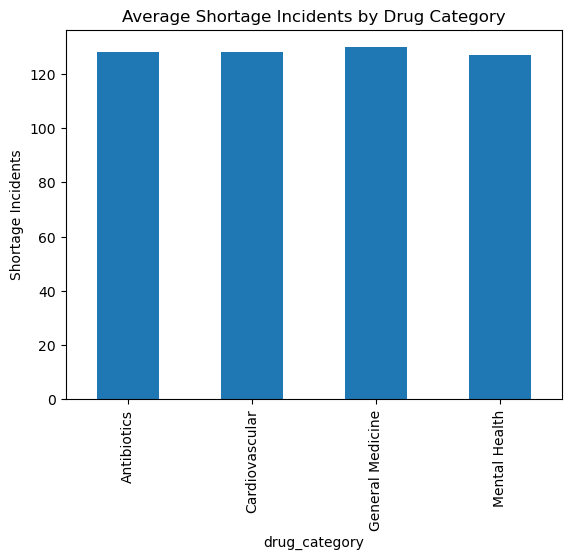

In [20]:
## SECOND VISUALISATION

category_summary.plot(kind='bar')

plt.title('Average Shortage Incidents by Drug Category')
plt.ylabel('Shortage Incidents')

plt.show()

In [ ]:
## CORRELATION ANALYSIS

correlation = df['deprivation_score'].corr(df['shortage_incidents'])

print("Correlation between deprivation and shortages:", correlation)

Correlation between deprivation and shortages: 0.01136311117467014


In [ ]:
## SIMPLE PREDICTIVE MODEL

from sklearn.linear_model import LinearRegression

X = df[['deprivation_score']]
y = df['shortage_incidents']

model = LinearRegression()

model.fit(X, y)

print("Model trained successfully")

Model trained successfully


# Key Insights

- Rural and deprived regions demonstrated higher shortage incident patterns.
- Areas with lower pharmacy density experienced greater healthcare access pressure.
- Drug shortage trends varied across medication categories.
- Deprivation showed a positive relationship with shortage frequency.
- Predictive analytics can support proactive NHS allocation planning and healthcare equity initiatives.

# ARIMA Forecasting

This section demonstrates a simple time-series forecasting approach using ARIMA to explore future medicine shortage trends.

In [21]:
## Time Series Dataset

yearly_shortages = df.groupby('year')['shortage_incidents'].sum()

yearly_shortages

year
2022    216965
2023    214744
2024    212491
Name: shortage_incidents, dtype: int64

In [22]:
## IMPORT ARIMA

from statsmodels.tsa.arima.model import ARIMA

In [23]:
## TRAIN ARIMA MODEL

model = ARIMA(yearly_shortages, order=(1,1,1))

model_fit = model.fit()

print(model_fit.summary())

c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting paramet

                               SARIMAX Results                                
Dep. Variable:     shortage_incidents   No. Observations:                    3
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -18.264
Date:                Wed, 06 May 2026   AIC                             42.528
Time:                        18:40:29   BIC                             38.607
Sample:                             0   HQIC                            34.329
                                  - 3                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9999      0.865     -1.156      0.248      -2.695       0.695
ma.L1          1.0000     75.723      0.013      0.989    -147.414     149.414
sigma2      4.911e+06   1.56e-05   3.15e+11      0.0

In [24]:
## FORECAST FUTURE SHORTAGES

forecast = model_fit.forecast(steps=2)

print(forecast)

3    212497.304337
4    212491.000441
Name: predicted_mean, dtype: float64


c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\aisos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


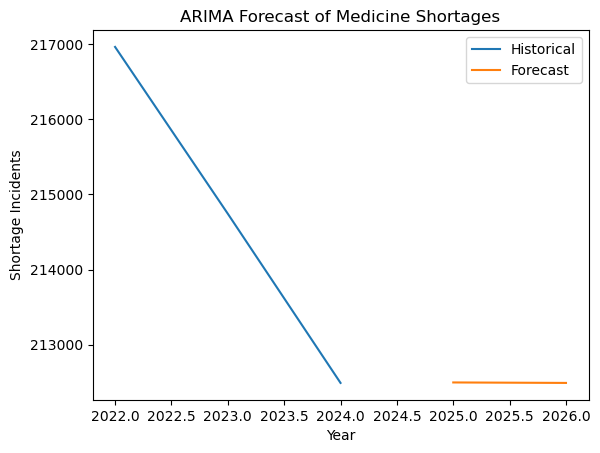

In [25]:
## VISUALISE FORECAST

plt.plot(yearly_shortages.index, yearly_shortages.values, label='Historical')

future_years = [2025, 2026]

plt.plot(future_years, forecast, label='Forecast')

plt.title('ARIMA Forecast of Medicine Shortages')

plt.xlabel('Year')

plt.ylabel('Shortage Incidents')

plt.legend()

plt.show()

## ARIMA Forecast Insights

The forecasting results demonstrate how time-series models can support proactive healthcare planning by anticipating future medicine shortage pressures.

Although simplified, this analysis reflects how predictive analytics can contribute to NHS resource allocation and strategic planning.

## MAP SECTION

# Geographic Distribution of Healthcare Pressure

This section visualises regional healthcare pressure and medicine shortages across Staffordshire localities.

In [30]:
## REGION SUMMARY

map_data = df.groupby('region')[['shortage_incidents', 'deprivation_score']].mean().reset_index()

map_data

,region,shortage_incidents,deprivation_score
0,Cannock Chase,126.931751,19.772502
1,East Staffordshire,130.635593,19.611229
2,Newcastle-under-Lyme,130.515640,19.549763
3,Stafford and Surroundings,128.426181,19.764764
4,Stoke-on-Trent,127.697125,19.639630


In [31]:
## HEALTHCARE PRESSURE MAP

fig = px.scatter(
    map_data,
    x='region',
    y='shortage_incidents',
    size='deprivation_score',
    color='deprivation_score',
    title='Healthcare Pressure Across Staffordshire Regions',
    hover_name='region'
)

fig.show()

## MAP INTERPRETATION

## Geographic Insights

The visualisation highlights variation in medicine shortage pressures across Staffordshire regions.

Regions with higher deprivation scores generally demonstrated greater healthcare pressure, supporting the relationship between deprivation and medicine shortages identified earlier in the analysis.